# Practice 2 — Part 1: Data Preparation


## Mục tiêu
- Tải dữ liệu CIFAR-10
- Tiền xử lý dữ liệu
- Chia train, validation và test
- Tạo DataLoader dùng chung
- Trực quan hóa dữ liệu

In [2]:
# Import Thư viện cêll 1
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch


# Tìm thư mục Practice_2
PROJECT_DIR = Path.cwd()

while (
    PROJECT_DIR.name != "Practice_2"
    and PROJECT_DIR.parent != PROJECT_DIR
):
    PROJECT_DIR = PROJECT_DIR.parent

if PROJECT_DIR.name != "Practice_2":
    raise FileNotFoundError(
        "Không tìm thấy thư mục Practice_2. "
        "Hãy mở notebook từ đúng repository."
    )

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("PROJECT_DIR:", PROJECT_DIR)

PROJECT_DIR: d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_2


In [7]:
# Cell 2 Kiểm tra Thư viện
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch


# Tìm thư mục Practice_2
PROJECT_DIR = Path.cwd()

while (
    PROJECT_DIR.name != "Practice_2"
    and PROJECT_DIR.parent != PROJECT_DIR
):
    PROJECT_DIR = PROJECT_DIR.parent

if PROJECT_DIR.name != "Practice_2":
    raise FileNotFoundError(
        "Không tìm thấy thư mục Practice_2. "
        "Hãy mở notebook từ đúng repository."
    )

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("PROJECT_DIR:", PROJECT_DIR)

PROJECT_DIR: d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_2


In [8]:
# Cell 3 Inport data pipeline
from src.data import (
    CIFAR10_CLASSES,
    IMAGENET_MEAN,
    IMAGENET_STD,
    DataConfig,
    build_dataloaders,
)


In [9]:
# cell 4 kiểm tra thiết bị 
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Thiết bị sử dụng:", device)
print("CUDA khả dụng:", torch.cuda.is_available())

Thiết bị sử dụng: cuda
CUDA khả dụng: True


In [10]:
# Cell 5 khai báo cấu hình
config = DataConfig(
    data_dir=PROJECT_DIR / "data",
    image_size=224,
    batch_size=32,
    val_ratio=0.10,
    num_workers=2,
    seed=42,
)

print(config)

DataConfig(data_dir=WindowsPath('d:/GTVT-UTH/HK_He_2026/DEEP_LEARNING/UTH-Deep-Learning-nhom2/Practice_2/data'), image_size=224, batch_size=32, val_ratio=0.1, num_workers=2, seed=42)


In [12]:
data_bundle = build_dataloaders(config)

train_dataset = data_bundle["train_dataset"]
val_dataset = data_bundle["val_dataset"]
test_dataset = data_bundle["test_dataset"]

train_loader = data_bundle["train_loader"]
val_loader = data_bundle["val_loader"]
test_loader = data_bundle["test_loader"]

class_names = data_bundle["class_names"]

100.0%


In [13]:
# cell 7 in thông tin dữ liệu 
print(f"Số mẫu train      : {len(train_dataset):,}")
print(f"Số mẫu validation : {len(val_dataset):,}")
print(f"Số mẫu test       : {len(test_dataset):,}")
print(f"Số lớp             : {len(class_names)}")
print(f"Batch size         : {config.batch_size}")

Số mẫu train      : 45,000
Số mẫu validation : 5,000
Số mẫu test       : 10,000
Số lớp             : 10
Batch size         : 32


In [14]:
# cell 8 Hiển thị tên các lớp
for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


In [15]:
# cell 9 Kiểm tra 1 batch
images, labels = next(iter(train_loader))

print("Kích thước images:", images.shape)
print("Kích thước labels:", labels.shape)
print("Kiểu dữ liệu ảnh:", images.dtype)
print("Giá trị nhãn đầu tiên:", labels[:10])

Kích thước images: torch.Size([32, 3, 224, 224])
Kích thước labels: torch.Size([32])
Kiểu dữ liệu ảnh: torch.float32
Giá trị nhãn đầu tiên: tensor([3, 1, 6, 3, 8, 9, 7, 9, 5, 0])


# Trực quan hóa một batch dữ liệu 

In [16]:
# cell Hàm khôi phục normalization
def denormalize_image(image: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(
        IMAGENET_MEAN,
        dtype=image.dtype,
        device=image.device,
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD,
        dtype=image.dtype,
        device=image.device,
    ).view(3, 1, 1)

    image = image * std + mean
    return image.clamp(0, 1)

In [25]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch


def show_batch(
    images: torch.Tensor,
    labels: torch.Tensor,
    class_names: list[str],
    number_of_images: int = 12,
    save_path: Path | None = None,
) -> None:
    """
    Hiển thị một batch ảnh và có thể lưu thành file PNG.
    """

    number_of_images = min(number_of_images, len(images))

    columns = 4
    rows = int(np.ceil(number_of_images / columns))

    plt.figure(figsize=(12, rows * 3))

    for index in range(number_of_images):
        image = denormalize_image(images[index])
        image = image.permute(1, 2, 0).cpu().numpy()

        plt.subplot(rows, columns, index + 1)
        plt.imshow(image)
        plt.title(class_names[labels[index].item()])
        plt.axis("off")

    plt.suptitle(
        "Sample Images from CIFAR-10 Training Set",
        fontsize=16,
        fontweight="bold",
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Phải lưu trước plt.show()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

        print(f"Đã lưu hình tại: {save_path.resolve()}")

    plt.show()
    plt.close()

### Nhận xét

- Các ảnh CIFAR-10 ban đầu có kích thước nhỏ và đã được resize lên 224 × 224.
- Tập train được áp dụng data augmentation như lật ngang, xoay nhẹ và thay đổi độ sáng.
- Các biến đổi giúp tăng tính đa dạng của dữ liệu và hỗ trợ giảm overfitting.
- Nhãn hiển thị phù hợp với 10 lớp của CIFAR-10.

Đã lưu hình tại: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_2\results\figures\cifar10_training_samples.png


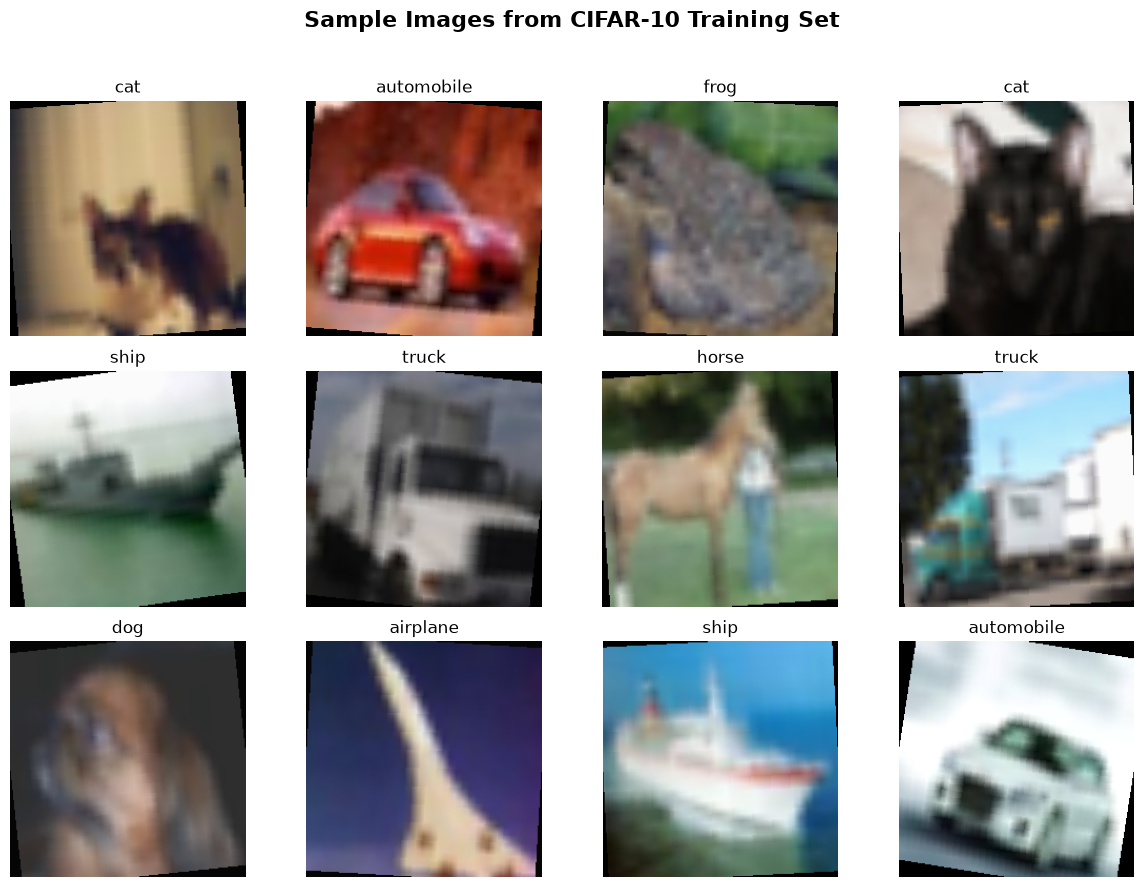

In [26]:
figure_path = (
    PROJECT_DIR
    / "results"
    / "figures"
    / "cifar10_training_samples.png"
)

show_batch(
    images=images,
    labels=labels,
    class_names=class_names,
    number_of_images=12,
    save_path=figure_path,
)

# Kiểm tra sự trùng lặp train-validation


In [18]:
# cell 12 
train_indices = set(data_bundle["train_indices"])
val_indices = set(data_bundle["val_indices"])

overlap = train_indices.intersection(val_indices)

print("Số index trùng nhau:", len(overlap))

Số index trùng nhau: 0


# Điều này chứng minh:

Một ảnh không đồng thời xuất hiện trong train và validation.
Hạn chế data leakage.
Kết quả validation phản ánh tốt hơn khả năng tổng quát hóa.

# Kiểm tra DataLoader validation và test 

In [19]:
#  cell 13 Kiểm tra số lượng mẫu trong mỗi lớp
val_images, val_labels = next(iter(val_loader))
test_images, test_labels = next(iter(test_loader))

print("Validation images:", val_images.shape)
print("Validation labels:", val_labels.shape)

print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

Validation images: torch.Size([32, 3, 224, 224])
Validation labels: torch.Size([32])
Test images: torch.Size([32, 3, 224, 224])
Test labels: torch.Size([32])


# Kiểm tra dữ liệu có thể đưa vào mô hình

In [20]:
# cell 14 images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

print("Thiết bị của images:", images.device)
print("Thiết bị của labels:", labels.device)

Thiết bị của images: cuda:0
Thiết bị của labels: cuda:0


In [ ]:
# thành viên 2, 3, 4, 5 và 6 sử dụng cùng đoạn code:
# Không thành viên nào được tự chia lại dữ liệu vì sẽ làm kết quả giữa các mô hình không còn công bằng.
from pathlib import Path
from src.data import DataConfig, build_dataloaders


config = DataConfig(
    data_dir=Path("data"),
    image_size=224,
    batch_size=32,
    val_ratio=0.10,
    num_workers=2,
    seed=42,
)

data_bundle = build_dataloaders(config)

train_loader = data_bundle["train_loader"]
val_loader = data_bundle["val_loader"]
test_loader = data_bundle["test_loader"]
class_names = data_bundle["class_names"]

num_classes = len(class_names)